# Torre de Transmissão — Minimização de Distâncias com Simulated Annealing

## Problema

Imagine que você precisa posicionar uma **torre de transmissão** (ou centro de distribuição) para atender a **três cidades** em coordenadas fixas.  
O objetivo é **minimizar a soma das distâncias** da torre a cada cidade:

$$f(x, y) = \sqrt{(x-x_1)^2 + (y-y_1)^2} + \sqrt{(x-x_2)^2 + (y-y_2)^2} + \sqrt{(x-x_3)^2 + (y-y_3)^2}$$

Este é o **Problema de Weber** (ou Fermat-Torricelli generalizado).  
Vamos resolvê-lo com **Simulated Annealing (SA)**.

---

## O que é Simulated Annealing?

Simulated Annealing é uma **metaheurística** inspirada no processo de recozimento de metais:
- Começa com uma solução aleatória e uma **temperatura** alta.
- A cada iteração, gera um **vizinho** da solução atual.
- Aceita o vizinho **sempre** se for melhor; aceita com **probabilidade** $e^{-\Delta f / T}$ se for pior.
- Vai **resfriando** gradualmente ($T \leftarrow \alpha \cdot T$), tornando-se mais seletivo.
- Ao final, converge para uma boa solução (idealmente o ótimo global).

## 1. Importações

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap

np.random.seed(42)

## 2. Definição do Problema

In [ ]:

cidades = np.array([
    [1.0, 2.0],  
    [5.0, 8.0],  
    [9.0, 3.0],   
])

nomes_cidades = ['Cidade A', 'Cidade B', 'Cidade C']

def f(pos, cidades):
    """Função objetivo: soma das distâncias euclidianas às cidades."""
    return np.sum(np.sqrt(np.sum((pos - cidades)**2, axis=1)))


pos_teste = np.array([5.0, 5.0])
print(f"f(5, 5) = {f(pos_teste, cidades):.4f}")

f(5, 5) = 12.4721


## 3. Algoritmo de Simulated Annealing

In [ ]:
def simulated_annealing(f, cidades, T0=100.0, alpha=0.995, T_min=1e-6,
                         max_iter=10000, passo=0.5):
    """
    Simulated Annealing para minimizar f(pos, cidades).

    Parâmetros
    ----------
    f        : função objetivo f(pos, cidades) -> float
    cidades  : array (n, 2) com coordenadas das cidades
    T0       : temperatura inicial
    alpha    : taxa de resfriamento (0 < alpha < 1)
    T_min    : temperatura mínima (critério de parada)
    max_iter : número máximo de iterações por temperatura
    passo    : amplitude máxima do perturbação (vizinhança)

    Retorna
    -------
    melhor_pos     : melhor posição encontrada
    melhor_custo   : menor custo encontrado
    historico      : lista de custos ao longo das iterações
    traj           : trajetória das posições aceitas
    """
   
    pos_atual = np.mean(cidades, axis=0) + np.random.uniform(-1, 1, 2)
    custo_atual = f(pos_atual, cidades)

    melhor_pos   = pos_atual.copy()
    melhor_custo = custo_atual

    T = T0
    historico = [custo_atual]
    traj = [pos_atual.copy()]

    iteracao = 0

    while T > T_min and iteracao < max_iter:
       
        perturbacao = np.random.uniform(-passo, passo, 2)
        pos_nova    = pos_atual + perturbacao
        custo_novo  = f(pos_nova, cidades)

        delta = custo_novo - custo_atual

        
        if delta < 0:
           
            aceitar = True
        else:
           
            prob = np.exp(-delta / T)
            aceitar = np.random.rand() < prob

        if aceitar:
            pos_atual   = pos_nova
            custo_atual = custo_novo
            traj.append(pos_atual.copy())

           
            if custo_atual < melhor_custo:
                melhor_pos   = pos_atual.copy()
                melhor_custo = custo_atual

        historico.append(custo_atual)

        
        T *= alpha
        iteracao += 1

    return melhor_pos, melhor_custo, historico, np.array(traj)



melhor_pos, melhor_custo, historico, traj = simulated_annealing(
    f, cidades,
    T0=100.0,
    alpha=0.995,
    T_min=1e-6,
    max_iter=20000,
    passo=0.5
)

print("=" * 45)
print("     RESULTADO — SIMULATED ANNEALING")
print("=" * 45)
print(f"  Posição ótima:  x = {melhor_pos[0]:.6f}")
print(f"                  y = {melhor_pos[1]:.6f}")
print(f"  Custo mínimo:  f  = {melhor_custo:.6f}")
print(f"  Iterações:        {len(historico)}")
print("=" * 45)

     RESULTADO — SIMULATED ANNEALING
  Posição ótima:  x = 5.217989
                  y = 4.836951
  Custo mínimo:  f  = 12.458351
  Iterações:        3676


## 4. Comparação com o Ponto de Fermat-Torricelli (referência analítica)

In [ ]:
from scipy.optimize import minimize


res = minimize(f, np.mean(cidades, axis=0), args=(cidades,), method='L-BFGS-B')
pos_ref  = res.x
custo_ref = res.fun

print(f"Referência (L-BFGS-B): x={pos_ref[0]:.6f}, y={pos_ref[1]:.6f}, f={custo_ref:.6f}")
print(f"Simul. Annealing:      x={melhor_pos[0]:.6f}, y={melhor_pos[1]:.6f}, f={melhor_custo:.6f}")
print(f"Diferença no custo:    {abs(melhor_custo - custo_ref):.2e}")

Referência (L-BFGS-B): x=5.219858, y=4.844837, f=12.458340
Simul. Annealing:      x=5.217989, y=4.836951, f=12.458351
Diferença no custo:    1.13e-05


## 5. Visualizações

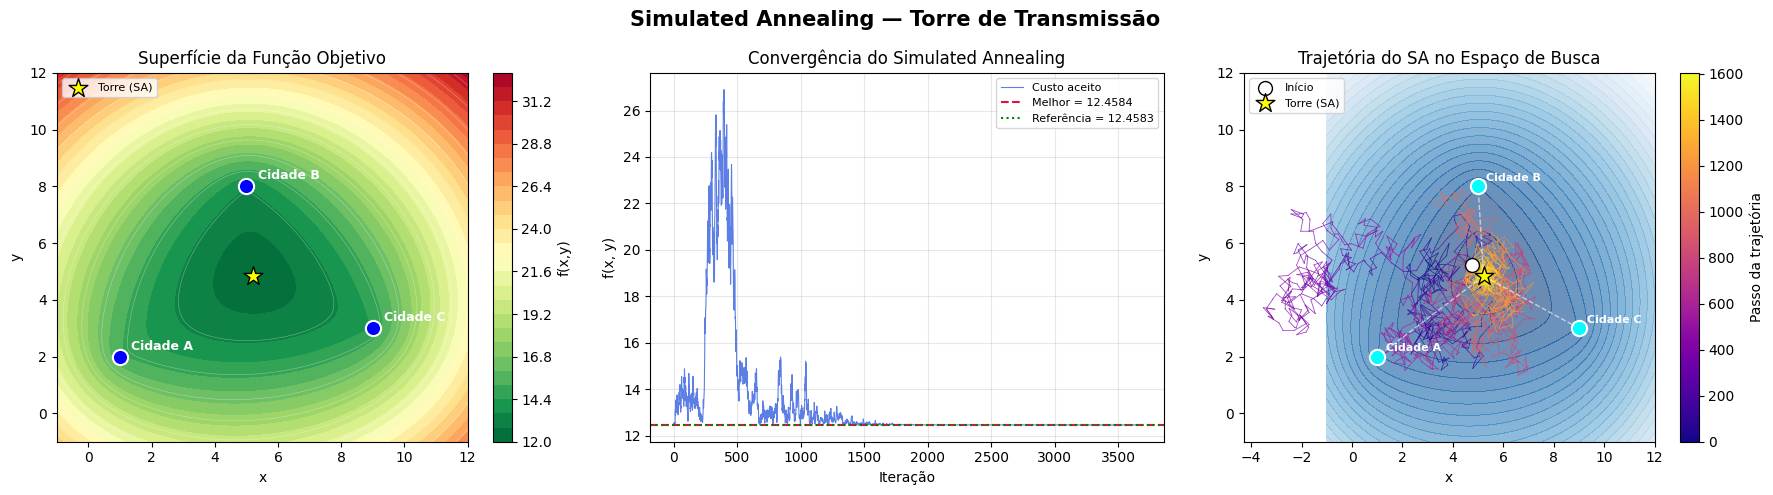

Figura salva em sa_torre_transmissao.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Simulated Annealing — Torre de Transmissão', fontsize=15, fontweight='bold')


ax1 = axes[0]
xs = np.linspace(-1, 12, 300)
ys = np.linspace(-1, 12, 300)
X, Y = np.meshgrid(xs, ys)
Z = np.zeros_like(X)
for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = f(np.array([X[i, j], Y[i, j]]), cidades)

cp = ax1.contourf(X, Y, Z, levels=30, cmap='RdYlGn_r')
plt.colorbar(cp, ax=ax1, label='f(x,y)')
ax1.contour(X, Y, Z, levels=15, colors='white', linewidths=0.4, alpha=0.4)

# Cidades
for i, (cx, cy) in enumerate(cidades):
    ax1.scatter(cx, cy, s=120, color='blue', zorder=5, edgecolors='white', linewidths=1.5)
    ax1.annotate(nomes_cidades[i], (cx, cy), textcoords='offset points',
                 xytext=(8, 5), fontsize=9, color='white', fontweight='bold')

ax1.scatter(*melhor_pos, s=200, color='yellow', marker='*', zorder=6,
            edgecolors='black', linewidths=1, label='Torre (SA)')
ax1.set_title('Superfície da Função Objetivo')
ax1.set_xlabel('x'); ax1.set_ylabel('y')
ax1.legend(loc='upper left', fontsize=8)



ax2 = axes[1]
ax2.plot(historico, color='royalblue', linewidth=0.8, alpha=0.85, label='Custo aceito')
ax2.axhline(melhor_custo, color='crimson', linestyle='--', linewidth=1.5,
            label=f'Melhor = {melhor_custo:.4f}')
ax2.axhline(custo_ref, color='green', linestyle=':', linewidth=1.5,
            label=f'Referência = {custo_ref:.4f}')
ax2.set_title('Convergência do Simulated Annealing')
ax2.set_xlabel('Iteração')
ax2.set_ylabel('f(x, y)')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)



ax3 = axes[2]
ax3.contourf(X, Y, Z, levels=30, cmap='Blues_r', alpha=0.6)

n_traj = len(traj)
cores = plt.cm.plasma(np.linspace(0, 1, n_traj))
for i in range(n_traj - 1):
    ax3.plot(traj[i:i+2, 0], traj[i:i+2, 1], color=cores[i], linewidth=0.6, alpha=0.7)

ax3.scatter(traj[0, 0], traj[0, 1], s=100, color='white', marker='o',
            zorder=5, edgecolors='black', label='Início')
ax3.scatter(*melhor_pos, s=200, color='yellow', marker='*', zorder=6,
            edgecolors='black', linewidths=1, label='Torre (SA)')

for i, (cx, cy) in enumerate(cidades):
    ax3.scatter(cx, cy, s=120, color='cyan', zorder=5, edgecolors='white', linewidths=1.5)
    ax3.plot([melhor_pos[0], cx], [melhor_pos[1], cy], 'w--', linewidth=1, alpha=0.6)
    ax3.annotate(nomes_cidades[i], (cx, cy), textcoords='offset points',
                 xytext=(6, 4), fontsize=8, color='white', fontweight='bold')

sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(0, n_traj))
sm.set_array([])
plt.colorbar(sm, ax=ax3, label='Passo da trajetória')

ax3.set_title('Trajetória do SA no Espaço de Busca')
ax3.set_xlabel('x'); ax3.set_ylabel('y')
ax3.legend(loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('sa_torre_transmissao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva em sa_torre_transmissao.png')

## 6. Análise de Sensibilidade — Efeito dos Hiperparâmetros

/tmp/ipykernel_9358/1922078456.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(dados, labels=labels, patch_artist=True,


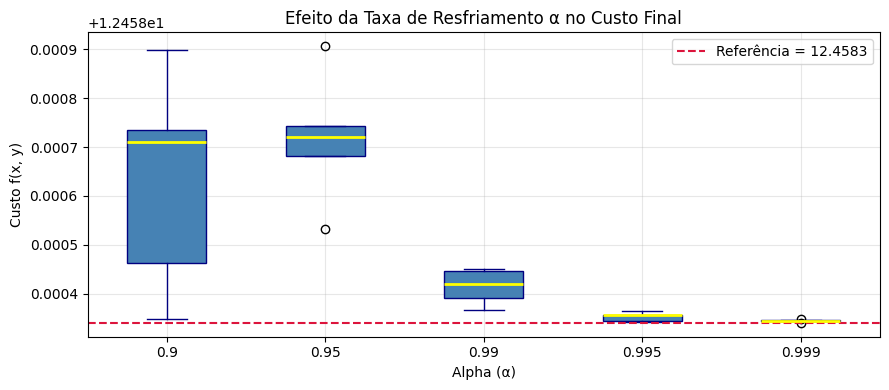

In [ ]:

alphas = [0.90, 0.95, 0.99, 0.995, 0.999]
resultados_alpha = {}

for a in alphas:
    custos_runs = []
    for _ in range(5):  
        _, c, _, _ = simulated_annealing(f, cidades, T0=100.0, alpha=a,
                                          T_min=1e-6, max_iter=20000, passo=0.5)
        custos_runs.append(c)
    resultados_alpha[a] = custos_runs

fig, ax = plt.subplots(figsize=(9, 4))
labels = [str(a) for a in alphas]
dados  = [resultados_alpha[a] for a in alphas]

bp = ax.boxplot(dados, labels=labels, patch_artist=True,
                boxprops=dict(facecolor='steelblue', color='navy'),
                medianprops=dict(color='yellow', linewidth=2),
                whiskerprops=dict(color='navy'),
                capprops=dict(color='navy'))

ax.axhline(custo_ref, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Referência = {custo_ref:.4f}')
ax.set_title('Efeito da Taxa de Resfriamento α no Custo Final')
ax.set_xlabel('Alpha (α)')
ax.set_ylabel('Custo f(x, y)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Resumo dos Resultados

In [9]:
print("\n" + "=" * 50)
print("         RESUMO FINAL")
print("=" * 50)
print(f"  Cidades:")
for i, (cidade, nome) in enumerate(zip(cidades, nomes_cidades)):
    dist = np.sqrt(np.sum((melhor_pos - cidade)**2))
    print(f"    {nome}: ({cidade[0]:.1f}, {cidade[1]:.1f})  →  distância = {dist:.4f}")
print()
print(f"  Torre posicionada em:  ({melhor_pos[0]:.6f}, {melhor_pos[1]:.6f})")
print(f"  Soma total distâncias: {melhor_custo:.6f}")
print(f"  Referência analítica:  {custo_ref:.6f}")
print(f"  Erro relativo:         {abs(melhor_custo - custo_ref)/custo_ref * 100:.4f}%")
print("=" * 50)


         RESUMO FINAL
  Cidades:
    Cidade A: (1.0, 2.0)  →  distância = 5.0833
    Cidade B: (5.0, 8.0)  →  distância = 3.1706
    Cidade C: (9.0, 3.0)  →  distância = 4.2045

  Torre posicionada em:  (5.217989, 4.836951)
  Soma total distâncias: 12.458351
  Referência analítica:  12.458340
  Erro relativo:         0.0001%
